In [1]:
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pandas as pd
import OptimalBattery.plot as plot
import OptimalBattery.global_config as gcf

save_dir = gcf.save_dir


In [7]:
eval_tsvs_dir = os.path.abspath(os.path.join(os.getcwd(),'..','eval_tsvs'))
saved_file = os.path.join(eval_tsvs_dir, 'real_connectivity.tsv')
D = pd.read_csv(saved_file, sep='\t')

In [8]:
# defube metrics to plot
metrics = ['random','variance','inverse_trace_mc','log_det_mc']
D = D[D['metric'].isin(metrics)]
n_subs = 24
D["sub"] = (D.index % n_subs) + 1

In [9]:
# Step 1: compute the group mean per n_task
task_mean = D.groupby("n_task")["avg_correlation_per_subject"].transform("mean")

# Step 2: compute each subject’s mean within that n_task
subject_mean = D.groupby(["n_task", "sub"])["avg_correlation_per_subject"].transform("mean")

# Step 3 & 4: remove subject effect, add group mean
D["adjusted"] = D["avg_correlation_per_subject"] - subject_mean + task_mean

In [10]:
custom_palette = {
    'random': 'black',
    'variance': '#0072B2',
    'variance_mc': '#009E73',
    'log_det_mc': '#E69F00',
    'inverse_trace_mc': '#D55E00'
}

custom_dashes = {
    'random': (1, 1),            # dotted
    'variance': (4, 2),              # dashed
    'variance_mc': (4, 2),           # dashed
    'log_det_mc': '',        # solid
    'inverse_trace_mc': '',  # solid
}

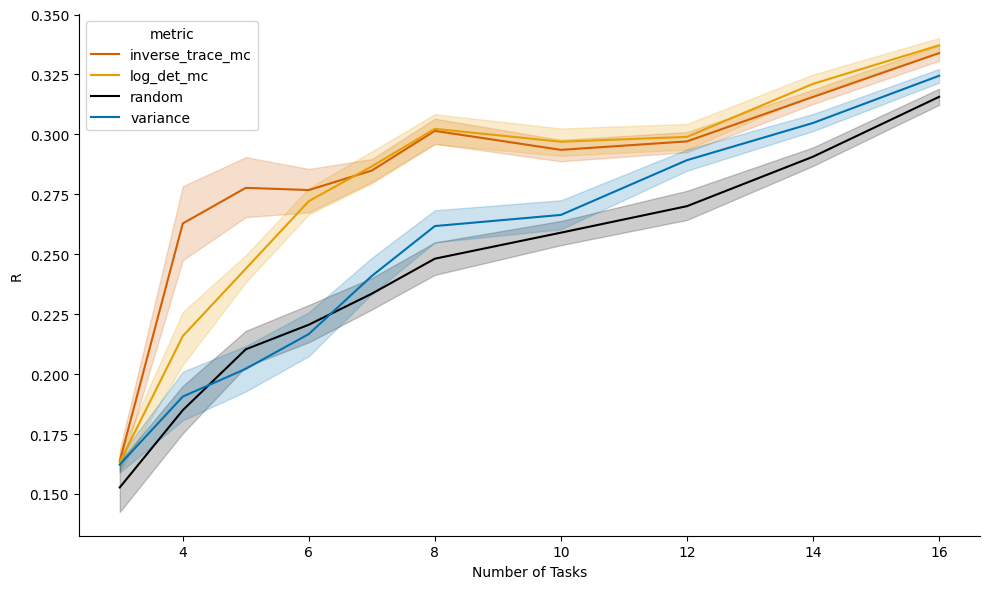

In [11]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=D,
    x="n_task",
    y="adjusted",
    hue="metric",
    palette=custom_palette,
)

plt.xlabel("Number of Tasks")
plt.ylabel("R")
# remove legend 
plt.tight_layout()
sns.despine()
plt.savefig(f"{save_dir}/battery_criteria/real_connectivity.pdf", format="pdf", bbox_inches="tight")
plt.show()